Kích thước tập Train: (1460, 81)
Kích thước tập Test: (1459, 80)
Các cột có giá trị thiếu (%>0):
 PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


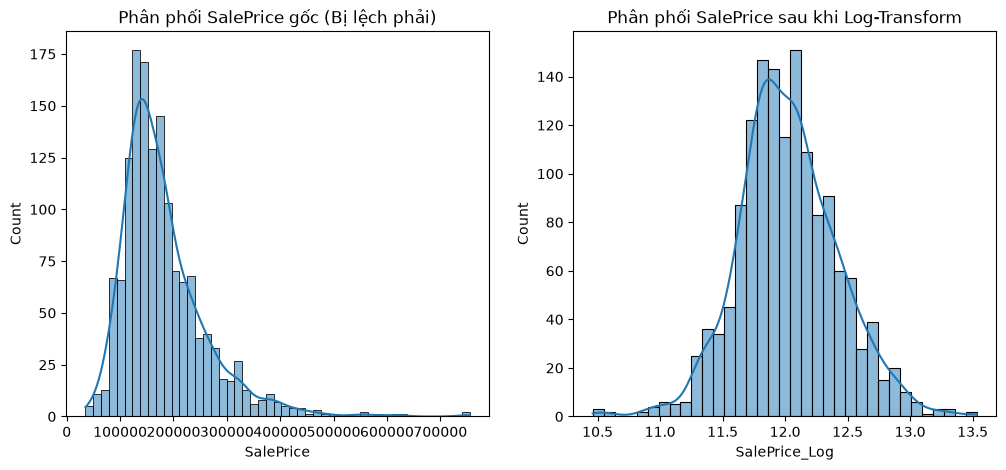

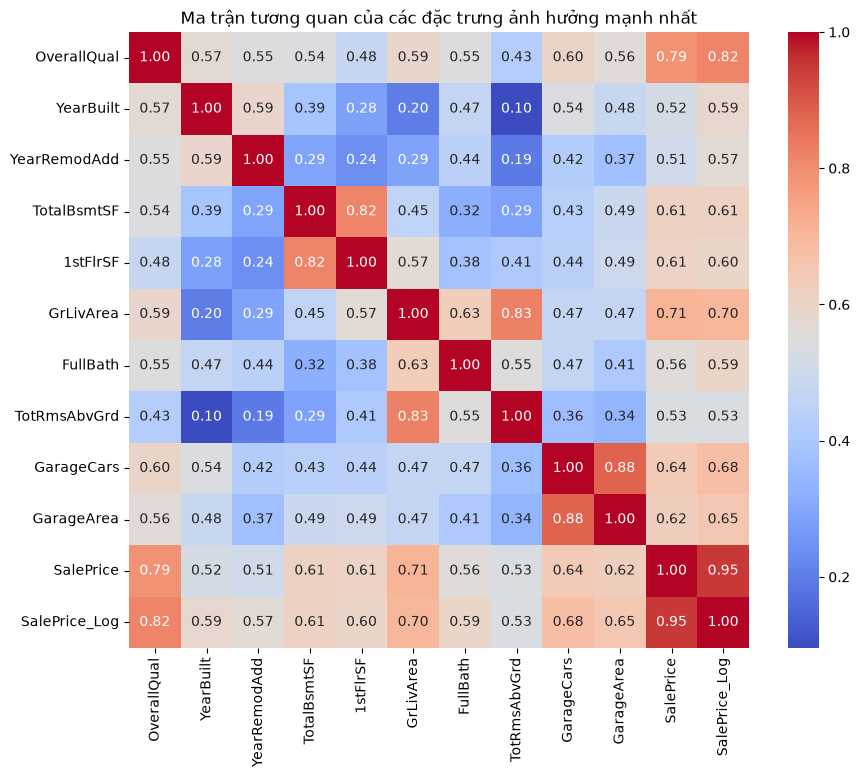

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ thư mục data gốc
train_df = pd.read_csv('../../data/train.csv')
test_df = pd.read_csv('../../data/test.csv')

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

# 2. Kiểm tra tỷ lệ dữ liệu bị thiếu (Missing Values)
missing_ratio = (train_df.isnull().sum() / len(train_df)) * 100
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)
print("Các cột có giá trị thiếu (%>0):\n", missing_ratio)

# 3. Phân tích biến mục tiêu (SalePrice)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('Phân phối SalePrice gốc (Bị lệch phải)')

# Log-transform SalePrice để phân phối chuẩn hơn (giúp mô hình học tốt hơn)
train_df['SalePrice_Log'] = np.log1p(train_df['SalePrice'])
plt.subplot(1, 2, 2)
sns.histplot(train_df['SalePrice_Log'], kde=True)
plt.title('Phân phối SalePrice sau khi Log-Transform')
plt.show()

# 4. Ma trận tương quan (Heatmap) với SalePrice
numeric_cols = train_df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
top_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]

plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan của các đặc trưng ảnh hưởng mạnh nhất")
plt.show()